<a href="https://colab.research.google.com/github/Arrsssa/-/blob/main/%EC%88%99%EC%A0%9C2(03.13).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

In [11]:
def load_data_from_api():
    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming"

    os.makedirs("data", exist_ok=True)

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()

        with open("data/launches.json", "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=4)

        print("JSON файл успешно сохранён: data/launches.json")

        df = pd.json_normalize(data["results"])
        print("DataFrame создан успешно")
        print(df.head())

        return df

    except requests.exceptions.RequestException as e:
        print(f"Ошибка при запросе к API: {e}")
        return None
    except Exception as e:
        print(f"Неожиданная ошибка: {e}")
        return None

In [12]:
df = load_data_from_api()

JSON файл успешно сохранён: data/launches.json
DataFrame создан успешно
                                     id  \
0  2e3e33a1-b87d-4d52-a7e7-8cc5a28046fd   
1  1d24bfe7-d524-41f0-85de-09e967618710   
2  6f2868b8-1000-48e5-893b-700c1371b4fb   
3  d44f47c7-5e3e-40fb-9d10-b6e851acf81a   
4  f8766455-2b03-4629-a36e-b931c8b4a6c5   

                                                 url launch_library_id  \
0  https://ll.thespacedevs.com/2.0.0/launch/2e3e3...              None   
1  https://ll.thespacedevs.com/2.0.0/launch/1d24b...              None   
2  https://ll.thespacedevs.com/2.0.0/launch/6f286...              None   
3  https://ll.thespacedevs.com/2.0.0/launch/d44f4...              None   
4  https://ll.thespacedevs.com/2.0.0/launch/f8766...              None   

                                    slug  \
0      long-march-8a-satnet-leo-group-20   
1          long-march-2d-shiyan-30-03-04   
2  falcon-9-block-5-starlink-group-10-48   
3  falcon-9-block-5-starlink-group-17-31   
4   

In [13]:
def get_pictures(limit=10):
    os.makedirs("images", exist_ok=True)

    try:
        with open("data/launches.json", "r", encoding="utf-8") as f:
            data = json.load(f)
    except FileNotFoundError:
        print("Файл data/launches.json не найден. Сначала запусти load_data_from_api().")
        return []

    launches = data.get("results", [])
    saved_files = []
    count = 0

    for i, launch in enumerate(launches):
        if count >= limit:
            break

        image_url = launch.get("image")
        name = launch.get("name", f"rocket_{i}")

        if not image_url:
            print(f"[{i}] У запуска '{name}' нет изображения.")
            continue

        try:
            response = requests.get(image_url, timeout=10)
            response.raise_for_status()

            file_ext = image_url.split(".")[-1].split("?")[0]
            if len(file_ext) > 5 or "/" in file_ext:
                file_ext = "jpg"

            filename = f"images/rocket_{count}.{file_ext}"

            with open(filename, "wb") as f:
                f.write(response.content)

            saved_files.append(filename)
            count += 1
            print(f"Сохранено: {filename}")

        except requests.exceptions.RequestException as e:
            print(f"[{i}] Ошибка скачивания изображения: {e}")
        except Exception as e:
            print(f"[{i}] Неожиданная ошибка: {e}")

    print(f"\nВсего сохранено изображений: {len(saved_files)}")
    return saved_files

In [14]:
image_files = get_pictures(limit=10)

Сохранено: images/rocket_0.jpeg
Сохранено: images/rocket_1.jpeg
Сохранено: images/rocket_2.png
Сохранено: images/rocket_3.png
Сохранено: images/rocket_4.jpeg
Сохранено: images/rocket_5.jpeg
Сохранено: images/rocket_6.png
Сохранено: images/rocket_7.png
Сохранено: images/rocket_8.png
Сохранено: images/rocket_9.jpeg

Всего сохранено изображений: 10


In [15]:
def show_images(image_folder="images", max_images=10):
    files = os.listdir(image_folder)
    files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))]

    if not files:
        print("В папке images нет изображений.")
        return

    files = files[:max_images]

    plt.figure(figsize=(15, 8))

    for i, file in enumerate(files):
        img_path = os.path.join(image_folder, file)

        try:
            img = Image.open(img_path)
            plt.subplot(2, 5, i + 1)
            plt.imshow(img)
            plt.title(file, fontsize=8)
            plt.axis("off")
        except Exception as e:
            print(f"Ошибка при открытии {file}: {e}")

    plt.tight_layout()
    plt.show()

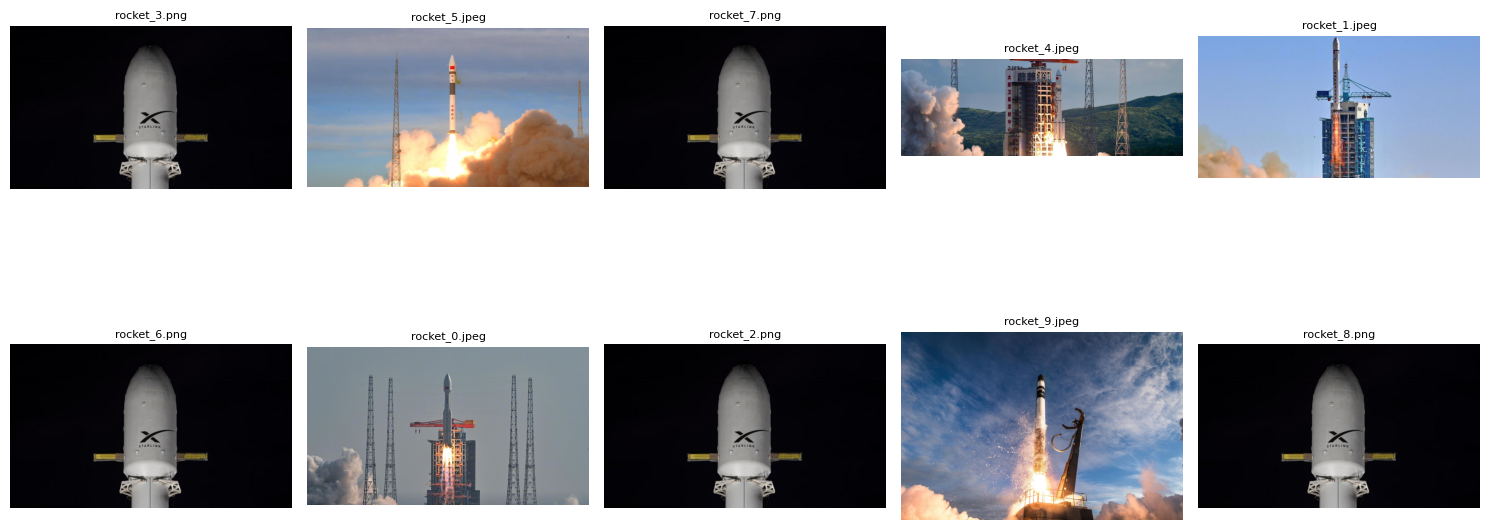

In [16]:
show_images(max_images=10)

In [17]:
def titanic_etl():
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

    os.makedirs("data", exist_ok=True)

    try:
        df = pd.read_csv(url)
        print("Titanic CSV успешно загружен")
        print(df.head())

        df_cleaned = df.dropna(subset=["Age"]).copy()
        df_cleaned["FamilySize"] = df_cleaned["SibSp"] + df_cleaned["Parch"] + 1

        df_cleaned.to_csv("data/titanic_cleaned.csv", index=False, encoding="utf-8-sig")
        print("Обработанный файл сохранён: data/titanic_cleaned.csv")

        return df_cleaned

    except Exception as e:
        print(f"Ошибка в Titanic ETL: {e}")
        return None

In [18]:
titanic_df = titanic_etl()

Titanic CSV успешно загружен
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450